In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
#import joblib
import shap
shap.initjs()

In [2]:

drop_list = ['symmetry_worst', 'area_worst', 'symmetry_se','radius_mean','concave points_worst',
            'compactness_se', 'concavity_se','smoothness_se','perimeter_mean','concave points_mean',
            'texture_se','radius_se','smoothness_mean','texture_mean','concave points_se',
            'area_mean','compactness_mean','perimeter_worst','Unnamed: 32', 'id']
#importing our cancer dataset
dataset = pd.read_csv('data.csv')
dataset = dataset.drop(drop_list, axis = 1)
X = dataset.drop(['diagnosis'], axis = 1)
Y = dataset['diagnosis']

In [3]:
#Encoding categorical data values
labelencoder_Y = LabelEncoder()
Y = labelencoder_Y.fit_transform(Y)

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [5]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [6]:
classifier = xgb.XGBClassifier()
classifier.fit(X_train_scaled, Y_train)
Y_pred = classifier.predict(X_test_scaled)

In [7]:
print(metrics.classification_report(Y_test, Y_pred))
print(metrics.confusion_matrix(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        90
           1       0.95      0.98      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

[[87  3]
 [ 1 52]]


In [8]:
# set feature names to classifier
classifier.feature_names = list(X.columns.values)

## SHAPIQ

In [9]:
#!pip install shapiq 
import shapiq
from tqdm.asyncio import tqdm

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Compute Shapley Interactions

In [10]:
# select a local instance to be explained
instance_id = 0
x_explain_actual = X_test.iloc[instance_id]
x_explain = X_test_scaled[instance_id]
y_true = Y_test[instance_id]
y_pred = classifier.predict(x_explain.reshape(1, -1))[0]
print(f"Instance {instance_id}, True Value: {y_true}, Predicted Value: {y_pred}")
for i, feature in enumerate(classifier.feature_names):
    print(f"{feature}: {x_explain_actual.iloc[i]}")

Instance 0, True Value: 1, Predicted Value: 1
concavity_mean: 0.1445
symmetry_mean: 0.2116
fractal_dimension_mean: 0.07325
perimeter_se: 3.093
area_se: 33.67
fractal_dimension_se: 0.004005
radius_worst: 16.41
texture_worst: 29.66
smoothness_worst: 0.1574
compactness_worst: 0.3856
concavity_worst: 0.5106
fractal_dimension_worst: 0.1109


In [11]:
# create explanations for different orders
si_order: dict[int, shapiq.InteractionValues] = {}
for order in tqdm([1, 2, len(classifier.feature_names)]):
    index = "k-SII" if order > 1 else "SV"  # will also be set automatically by the explainer
    explainer = shapiq.Explainer(model=classifier, data=X_train_scaled, max_order=order, index=index)
    si_order[order] = explainer.explain(x=x_explain)
si_order

  0%|                                                                                                                                                                             | 0/3 [00:00<?, ?it/s]

 33%|███████████████████████████████████████████████████████                                                                                                              | 1/3 [00:00<00:00,  7.82it/s]

 67%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                       | 2/3 [00:00<00:00,  6.22it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.98it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  4.47it/s]

{1: InteractionValues(
     index=SV, max_order=1, min_order=0, estimated=False, estimation_budget=None,
     n_players=12, baseline_value=0.2453565546543887
 ),
 2: InteractionValues(
     index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=None,
     n_players=12, baseline_value=0.2453565546543887
 ),
 12: InteractionValues(
     index=k-SII, max_order=12, min_order=0, estimated=False, estimation_budget=None,
     n_players=12, baseline_value=0.2453565546543887
 )}

### Visualize the Shapley Interactions

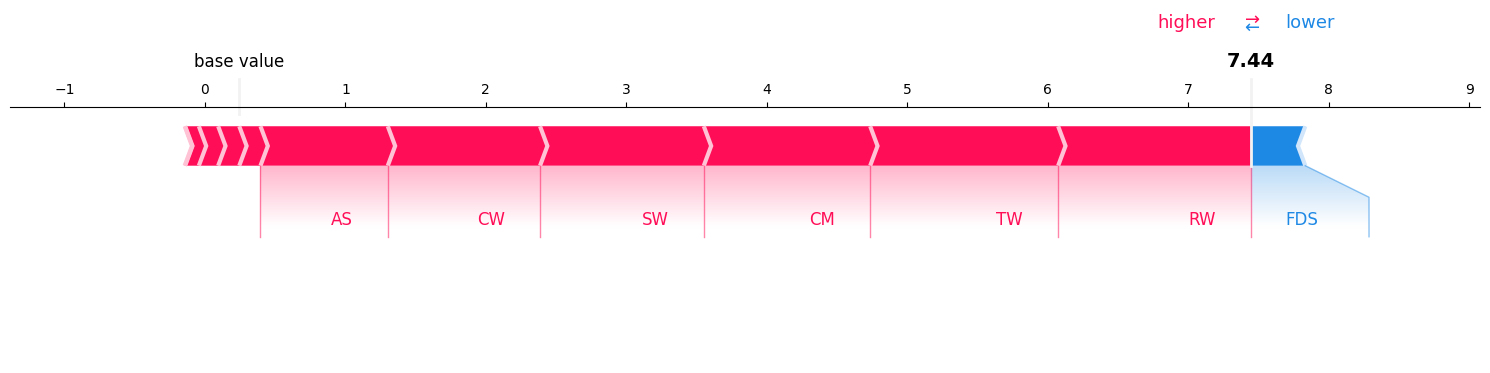

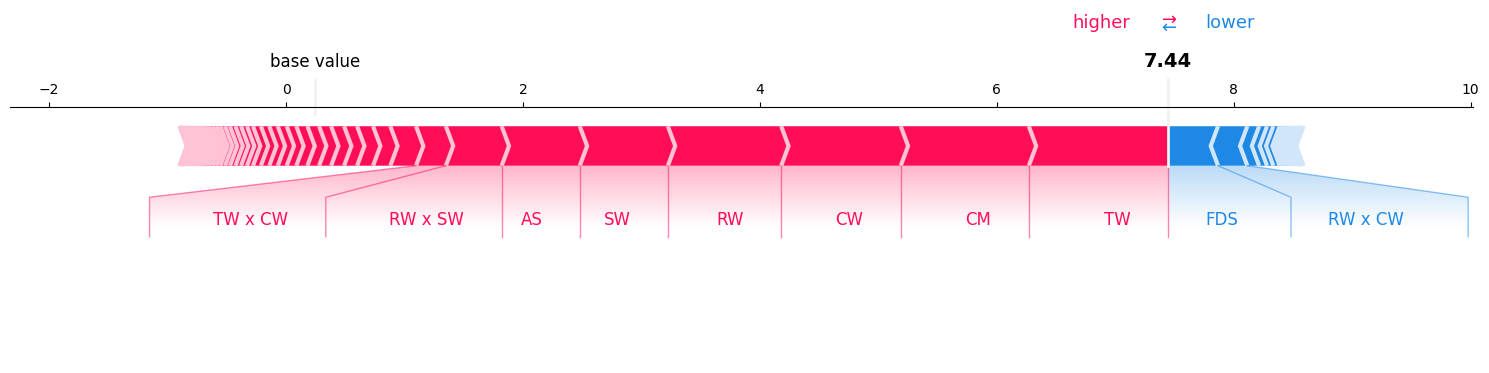

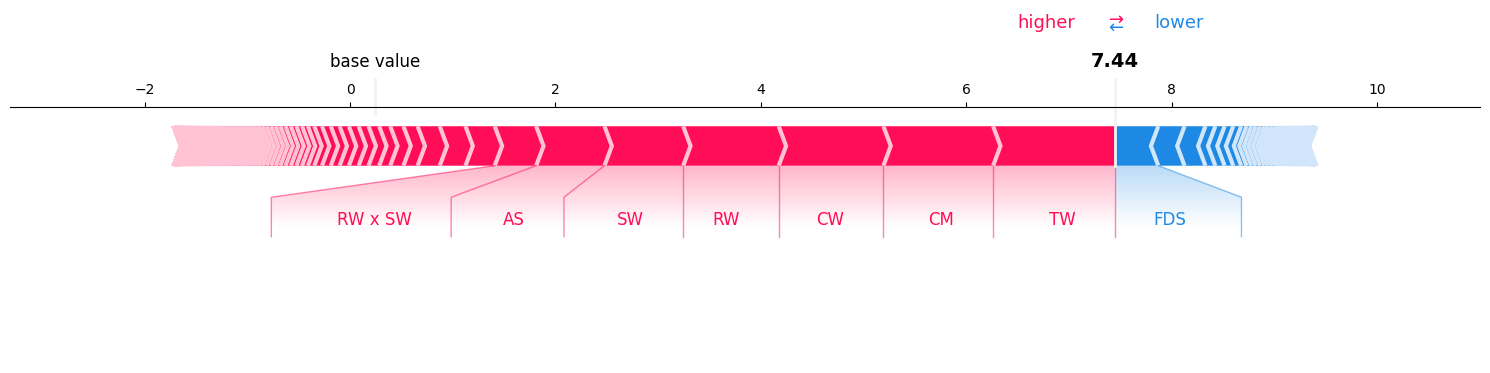

In [12]:
sv = si_order[1]  # get the SV
si = si_order[2]  # get the 2-SII
mi = si_order[len(classifier.feature_names)]  # get the Moebius transform

sv.plot_force(feature_names=classifier.feature_names, show=True)
si.plot_force(feature_names=classifier.feature_names, show=True)
mi.plot_force(feature_names=classifier.feature_names, show=True)

In [13]:
X_test_scaled[0]

array([ 0.71214153,  1.12533599,  1.55356719,  0.1223834 , -0.14498321,
        0.11123962,  0.01905951,  0.66396802,  1.08702447,  0.87505243,
        1.21700274,  1.53928319])

In [14]:
# Create SHAP explainer
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_scaled[0].reshape(1, -1))

shap_values:  [[ 1.1844642   0.1501946  -0.07178954 -0.09607071  0.59316266 -0.3014957
   1.4617031   1.1465104   1.3552241   0.12591067  1.3031968   0.3481194 ]]
expected_value:  -0.6462273
prob_expected_value:  0.3438402
prob_shap_values:  [[ 0.40726644  0.05164294 -0.02468413 -0.03303297  0.20395318 -0.10366635
   0.5025923   0.3942164   0.46598056  0.04329315  0.44809148  0.11969745]]


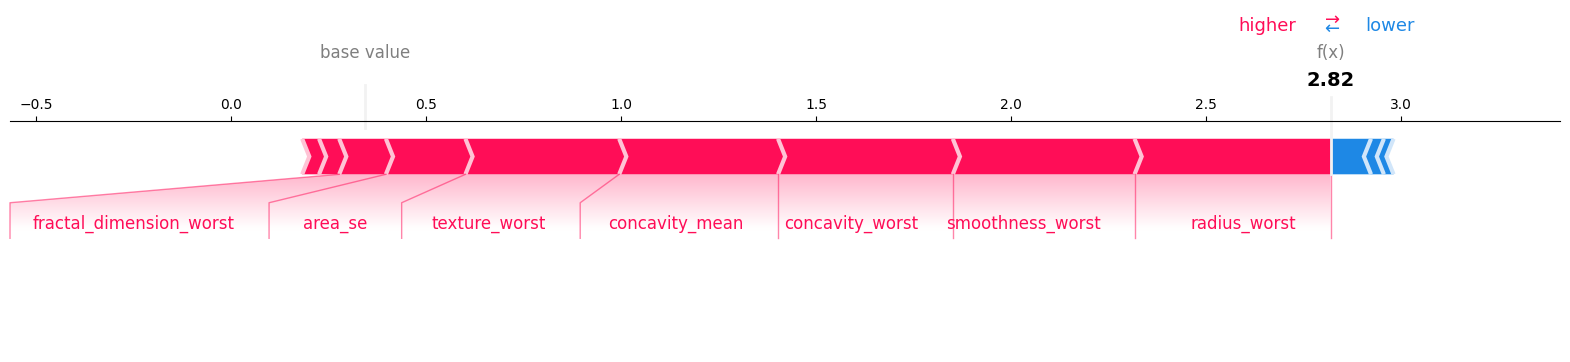

In [15]:
#explainer = shap.Explainer(classifier, X_test_scaled[0])
# If using a classifier that outputs log-odds, convert back to probability space
expected_value = explainer.expected_value
#shap_values_row_0 = explainer(X_test_scaled[0].reshape(1, -1))
print("shap_values: ", shap_values)
print("expected_value: ", expected_value)

#if isinstance(expected_value, np.ndarray):  # For multiclass case
#    expected_value = expected_value[0]

#if isinstance(shap_values, list):  # For multi-class classifiers
#    shap_values = shap_values[0]  # Select class 0 or choose the relevant class

# Ensure SHAP values are in probability space
prob_expected_value = 1 / (1 + np.exp(-expected_value))
prob_shap_values = shap_values / (1 + np.exp(-expected_value))  # Convert SHAP values
print("prob_expected_value: ", prob_expected_value)
print("prob_shap_values: ", prob_shap_values)

# Now use force_plot **without** link='logit'
shap.force_plot(prob_expected_value, prob_shap_values, feature_names=classifier.feature_names, matplotlib=True)

# SHAP

In [16]:
plt.figure(figsize=(10,7))
feat_importances = pd.Series(classifier.feature_importances_, index=X.columns)
feature_importances = pd.Series((classifier.feature_importances_ / sum(classifier.feature_importances_)), index=X.columns)
feature_importances.nlargest(20).plot(kind='barh')
plt.xlabel("importance")
plt.ylabel("features")
#plt.savefig('FI.png', bbox_inches='tight')

Text(0, 0.5, 'features')

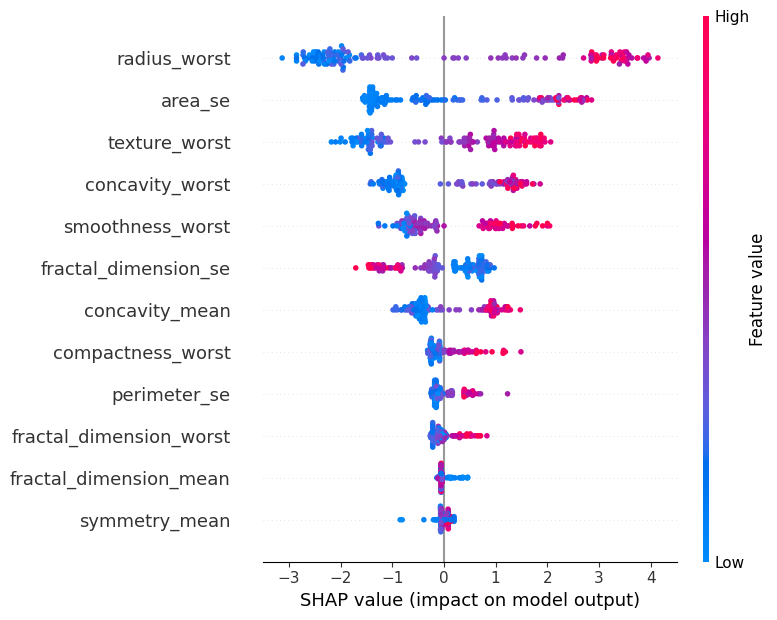

In [17]:
explainer = shap.Explainer(classifier, X_test_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)

#plt.savefig('global_shap.jpeg' ,bbox_inches='tight')
plt.show()


In [18]:
row_to_show = 0
data_for_prediction = X_test_scaled[row_to_show]  # use 1 row of data here. Could use multiple rows if desired
print(data_for_prediction)
data_for_prediction_array = data_for_prediction.reshape(1, -1)


# Create object that can calculate shap values
explainer = shap.TreeExplainer(classifier)
# Calculate Shap values
shap_values = explainer.shap_values(data_for_prediction_array)

shap.force_plot(explainer.expected_value, shap_values[0], data_for_prediction, link='logit')

[ 0.71214153  1.12533599  1.55356719  0.1223834  -0.14498321  0.11123962
  0.01905951  0.66396802  1.08702447  0.87505243  1.21700274  1.53928319]


expected value in log-odds space:  -0.6462273


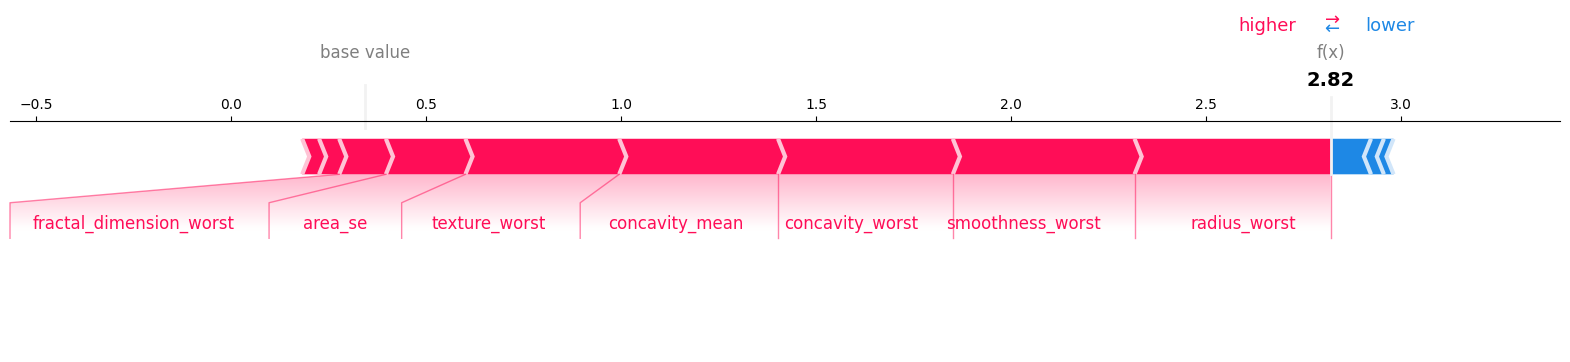

In [19]:
# If using a classifier that outputs log-odds, convert back to probability space
expected_value = explainer.expected_value
print("expected value in log-odds space: ", expected_value)
if isinstance(expected_value, np.ndarray):  # For multiclass case
    expected_value = expected_value[0]

if isinstance(shap_values, list):  # For multi-class classifiers
    shap_values = shap_values[0]  # Select class 0 or choose the relevant class

# Ensure SHAP values are in probability space
# Convert expected value to probability space
expected_value_prob = 1 / (1 + np.exp(-expected_value))

# Convert each SHAP value contribution from log-odds to probability
shap_values_prob = np.array(shap_values[0]) * expected_value_prob * (1 - expected_value_prob)

# Initialize JS visualization
#shap.initjs()

# Now use force_plot **without** link='logit'
shap.force_plot(prob_expected_value, prob_shap_values, feature_names=X.columns, link="identity", matplotlib=True)
#shap.force_plot(expected_value_prob, shap_values_prob, data_for_prediction, link="identity", matplotlib=True)


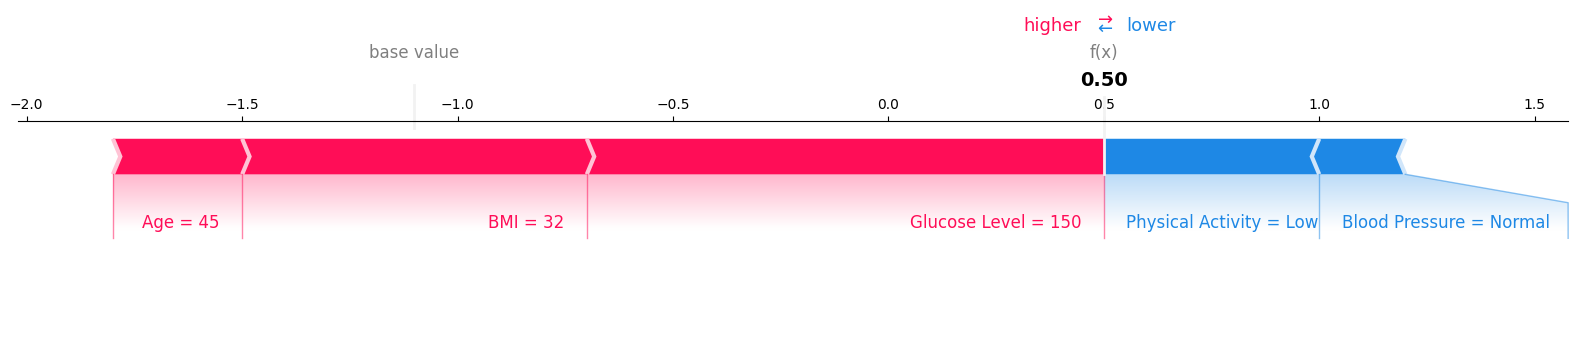

In [20]:
# Example SHAP values for one patient
expected_value = -1.1  # Base value in log-odds
shap_values = np.array([1.2, 0.8, 0.3, -0.5, -0.2])  # SHAP values for features
features = ["Glucose Level", "BMI", "Age", "Physical Activity", "Blood Pressure"]
data_for_prediction = np.array([150, 32, 45, "Low", "Normal"])  # Feature values

# Initialize JS for visualization
shap.initjs()

# Create a force plot
shap.force_plot(expected_value, shap_values, data_for_prediction, feature_names=features, matplotlib=True)

# Save model

In [21]:
# save model as cancer
#joblib.dump(classifier, 'cancer')

# Read Model

In [22]:
# load the saved model
#loaded_model = joblib.load('cancer')

In [23]:
# read the feature names from saved model
#f_names = loaded_model.feature_names